In [ ]:
'''
Rule-Based Systems in Uncertain Environments

Mamdani Fuzzy Inference System
Target group: second-year Computer Science students
Topic: rule-based reasoning under uncertainty
Model: Mamdani fuzzy inference with centroid defuzzification

In many real systems, input data is not perfectly precise. Sensors are noisy, human descriptions are vague, and exact thresholds are often artificial.
A fuzzy rule-based system handles this by using linguistic values such as low visibility, close obstacle, or safe speed, instead of only strict Boolean conditions.
'''

In [ ]:
'''
The robot receives three uncertain input values:

Visibility: from 0 to 100 percent
Obstacle distance: from 0 to 10 meters
Battery level: from 0 to 100 percent
The system must output one crisp value:

Recommended speed: from 0 to 10 km/h
'''

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

A membership function maps a crisp value to a degree between 0 and 1

In [2]:
def triangular(x, a, b, c):
    """
    Triangular membership function.

    Parameters:
    x : array-like
        Universe of discourse.
    a, b, c : float
        Triangle parameters, where a <= b <= c.

    Returns:
    array-like
        Membership degree for each x.
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    if a != b:
        left = (x >= a) & (x <= b)
        y[left] = (x[left] - a) / (b - a)

    if b != c:
        right = (x >= b) & (x <= c)
        y[right] = (c - x[right]) / (c - b)

    y[x == b] = 1.0
    return np.clip(y, 0, 1)


def trapezoidal(x, a, b, c, d):
    """
    Trapezoidal membership function.

    Parameters:
    x : array-like
        Universe of discourse.
    a, b, c, d : float
        Trapezoid parameters, where a <= b <= c <= d.

    Returns:
    array-like
        Membership degree for each x.
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    if a != b:
        rising = (x >= a) & (x <= b)
        y[rising] = (x[rising] - a) / (b - a)

    plateau = (x >= b) & (x <= c)
    y[plateau] = 1.0

    if c != d:
        falling = (x >= c) & (x <= d)
        y[falling] = (d - x[falling]) / (d - c)

    return np.clip(y, 0, 1)


def membership_at(value, universe, membership_values):
    """
    Interpolates the membership degree of a crisp value
    in a fuzzy set defined over a universe.
    """
    return np.interp(value, universe, membership_values)

Define the universes of discourse

In [3]:
visibility = np.linspace(0, 100, 501)       # percentage
distance = np.linspace(0, 10, 501)          # meters
battery = np.linspace(0, 100, 501)          # percentage
speed = np.linspace(0, 10, 501)             # km/h

Define the fuzzy sets
Input 1: Visibility
low
medium
high
Input 2: Obstacle distance
close
medium
far
Input 3: Battery level
low
medium
high
Output: Recommended speed
very slow
slow
moderate
fast

In [4]:
visibility_sets = {
    "low": trapezoidal(visibility, 0, 0, 20, 45),
    "medium": triangular(visibility, 25, 50, 75),
    "high": trapezoidal(visibility, 55, 80, 100, 100)
}

distance_sets = {
    "close": trapezoidal(distance, 0, 0, 1.5, 3.5),
    "medium": triangular(distance, 2, 5, 8),
    "far": trapezoidal(distance, 6, 8, 10, 10)
}

battery_sets = {
    "low": trapezoidal(battery, 0, 0, 20, 40),
    "medium": triangular(battery, 25, 50, 75),
    "high": trapezoidal(battery, 60, 80, 100, 100)
}

speed_sets = {
    "very_slow": trapezoidal(speed, 0, 0, 1, 2.5),
    "slow": triangular(speed, 1.5, 3, 4.5),
    "moderate": triangular(speed, 3.5, 5.5, 7.5),
    "fast": trapezoidal(speed, 6.5, 8, 10, 10)
}

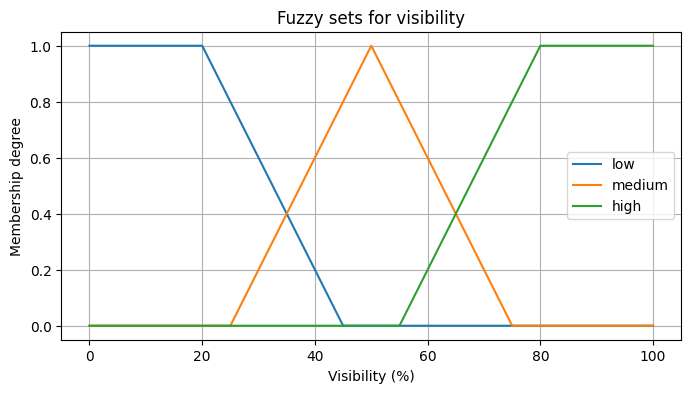

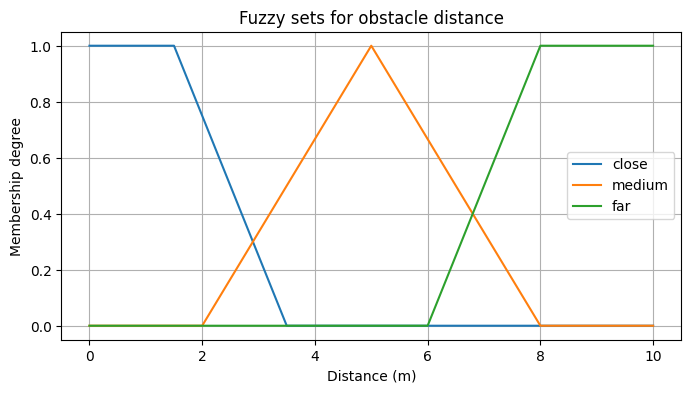

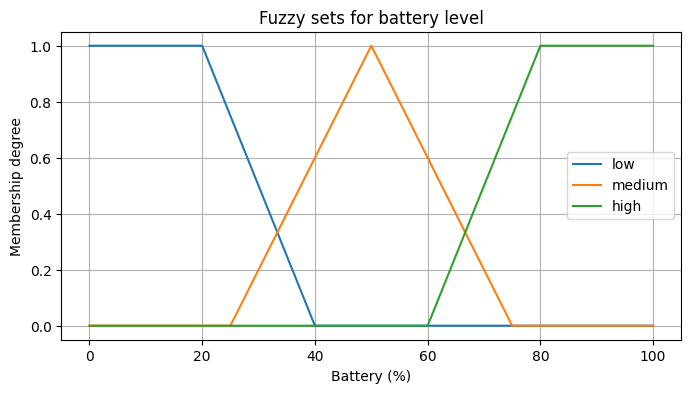

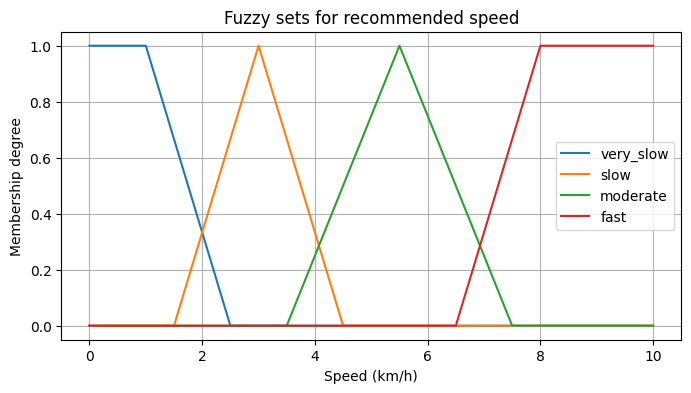

In [5]:
def plot_sets(universe, sets, title, xlabel):
    plt.figure(figsize=(8, 4))
    for name, values in sets.items():
        plt.plot(universe, values, label=name)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Membership degree")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()


plot_sets(visibility, visibility_sets, "Fuzzy sets for visibility", "Visibility (%)")
plot_sets(distance, distance_sets, "Fuzzy sets for obstacle distance", "Distance (m)")
plot_sets(battery, battery_sets, "Fuzzy sets for battery level", "Battery (%)")
plot_sets(speed, speed_sets, "Fuzzy sets for recommended speed", "Speed (km/h)")

Fuzzification - transform crisp inputs into fuzzy membership degrees

In [6]:
input_visibility = 42
input_distance = 3.2
input_battery = 65

fuzzified_visibility = {
    name: membership_at(input_visibility, visibility, values)
    for name, values in visibility_sets.items()
}

fuzzified_distance = {
    name: membership_at(input_distance, distance, values)
    for name, values in distance_sets.items()
}

fuzzified_battery = {
    name: membership_at(input_battery, battery, values)
    for name, values in battery_sets.items()
}

print("Fuzzified visibility:", fuzzified_visibility)
print("Fuzzified distance:", fuzzified_distance)
print("Fuzzified battery:", fuzzified_battery)

Fuzzified visibility: {'low': np.float64(0.12), 'medium': np.float64(0.68), 'high': np.float64(0.0)}
Fuzzified distance: {'close': np.float64(0.1499999999999999), 'medium': np.float64(0.4000000000000001), 'far': np.float64(0.0)}
Fuzzified battery: {'low': np.float64(0.0), 'medium': np.float64(0.4), 'high': np.float64(0.25)}


Rule base
and = modeled by min
or = modeled by max
implication is modeled by clipping the output fuzzy set with min
aggregation is modeled by max
RULES
1.IF visibility is low OR obstacle distance is close THEN speed is very slow
2.IF visibility is medium AND obstacle distance is close THEN speed is very slow
3.IF visibility is medium AND obstacle distance is medium THEN speed is slow
4.IF visibility is high AND obstacle distance is medium THEN speed is moderate
5.IF visibility is high AND obstacle distance is far AND battery is high THEN speed is fast
6.IF battery is low AND obstacle distance is far THEN speed is moderate
7.IF battery is low AND obstacle distance is close THEN speed is very slow
8.IF visibility is medium AND battery is medium AND obstacle distance is far THEN speed is moderate

In [8]:
def fuzzy_and(*values):
    return np.min(values)


def fuzzy_or(*values):
    return np.max(values)


def apply_rule(strength, output_set):
    """
    Mamdani implication: clip the consequent fuzzy set
    at the rule activation strength.
    """
    return np.minimum(strength, output_set)


def aggregate_outputs(*outputs):
    """
    Mamdani aggregation: combine all clipped consequents using max.
    """
    return np.maximum.reduce(outputs)


def centroid_defuzzification(universe, aggregated_membership):
    """
    Computes the crisp value using the centroid method.

    crisp_value = sum(x * mu(x)) / sum(mu(x))
    """
    denominator = np.sum(aggregated_membership)

    if denominator == 0:
        return np.nan

    return np.sum(universe * aggregated_membership) / denominator

mamdani interface function
fuzzify the crisp inputs;
compute rule activation strengths;
clip each consequent fuzzy set;
aggregate the clipped outputs;
defuzzify the result using centroid.

In [9]:
def mamdani_robot_speed(input_visibility, input_distance, input_battery, verbose=True):
    # Fuzzification
    V = {
        name: membership_at(input_visibility, visibility, values)
        for name, values in visibility_sets.items()
    }

    D = {
        name: membership_at(input_distance, distance, values)
        for name, values in distance_sets.items()
    }

    B = {
        name: membership_at(input_battery, battery, values)
        for name, values in battery_sets.items()
    }

    # Rule activation strengths
    rules = []

    strength = fuzzy_or(V["low"], D["close"])
    rules.append(("R1: low visibility OR close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["close"])
    rules.append(("R2: medium visibility AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["medium"])
    rules.append(("R3: medium visibility AND medium obstacle -> slow", strength, "slow"))

    strength = fuzzy_and(V["high"], D["medium"])
    rules.append(("R4: high visibility AND medium obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(V["high"], D["far"], B["high"])
    rules.append(("R5: high visibility AND far obstacle AND high battery -> fast", strength, "fast"))

    strength = fuzzy_and(B["low"], D["far"])
    rules.append(("R6: low battery AND far obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(B["low"], D["close"])
    rules.append(("R7: low battery AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], B["medium"], D["far"])
    rules.append(("R8: medium visibility AND medium battery AND far obstacle -> moderate", strength, "moderate"))

    # Apply Mamdani implication
    clipped_outputs = []
    for _, strength, consequent_name in rules:
        clipped_outputs.append(apply_rule(strength, speed_sets[consequent_name]))

    # Aggregate all rule conclusions
    aggregated = aggregate_outputs(*clipped_outputs)

    # Defuzzification
    crisp_speed = centroid_defuzzification(speed, aggregated)

    if verbose:
        print("Input values")
        print(f"  Visibility: {input_visibility}%")
        print(f"  Obstacle distance: {input_distance} m")
        print(f"  Battery level: {input_battery}%")
        print()

        print("Fuzzified inputs")
        print("  Visibility:", V)
        print("  Distance:", D)
        print("  Battery:", B)
        print()

        print("Rule activations")
        for rule_text, strength, consequent_name in rules:
            print(f"  {rule_text}: strength = {strength:.3f}")

        print()
        print(f"Crisp recommended speed: {crisp_speed:.2f} km/h")

    return crisp_speed, aggregated, rules

In [10]:
crisp_speed, aggregated_output, rules = mamdani_robot_speed(
    input_visibility=42,
    input_distance=3.2,
    input_battery=65
)

Input values
  Visibility: 42%
  Obstacle distance: 3.2 m
  Battery level: 65%

Fuzzified inputs
  Visibility: {'low': np.float64(0.12), 'medium': np.float64(0.68), 'high': np.float64(0.0)}
  Distance: {'close': np.float64(0.1499999999999999), 'medium': np.float64(0.4000000000000001), 'far': np.float64(0.0)}
  Battery: {'low': np.float64(0.0), 'medium': np.float64(0.4), 'high': np.float64(0.25)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.150
  R2: medium visibility AND close obstacle -> very slow: strength = 0.150
  R3: medium visibility AND medium obstacle -> slow: strength = 0.400
  R4: high visibility AND medium obstacle -> moderate: strength = 0.000
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.000
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: strength 

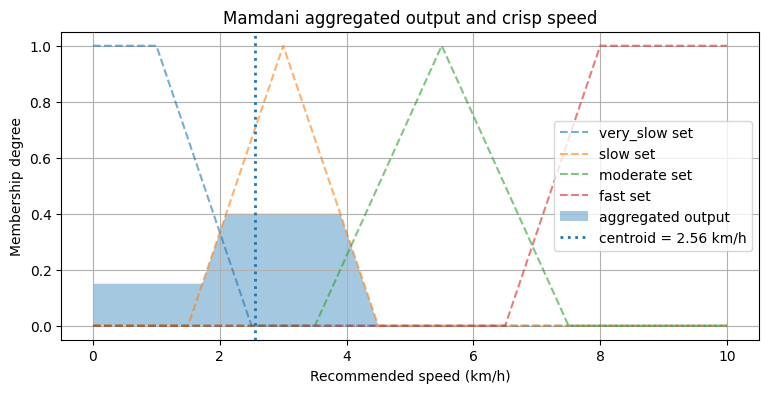

In [11]:
plt.figure(figsize=(9, 4))

for name, values in speed_sets.items():
    plt.plot(speed, values, linestyle="--", alpha=0.6, label=f"{name} set")

plt.fill_between(speed, aggregated_output, alpha=0.4, label="aggregated output")
plt.axvline(crisp_speed, linestyle=":", linewidth=2, label=f"centroid = {crisp_speed:.2f} km/h")

plt.title("Mamdani aggregated output and crisp speed")
plt.xlabel("Recommended speed (km/h)")
plt.ylabel("Membership degree")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [12]:
test_cases = [
    (20, 1.0, 90),   # poor visibility, close obstacle, high battery
    (90, 9.0, 90),   # excellent situation
    (70, 4.0, 30),   # acceptable visibility, medium obstacle, low battery
    (45, 7.5, 55),   # medium visibility, far obstacle, medium battery
    (80, 2.0, 80),   # high visibility but close obstacle
    (30, 8.0, 20),   # low visibility, far obstacle, low battery
]

results = []

for v, d, b in test_cases:
    crisp, _, _ = mamdani_robot_speed(v, d, b, verbose=False)
    results.append((v, d, b, crisp))

print("Visibility | Distance | Battery | Recommended speed")
print("-" * 52)
for v, d, b, crisp in results:
    print(f"{v:10.1f} | {d:8.1f} | {b:7.1f} | {crisp:17.2f}")

Visibility | Distance | Battery | Recommended speed
----------------------------------------------------
      20.0 |      1.0 |    90.0 |              0.92
      90.0 |      9.0 |    90.0 |              8.60
      70.0 |      4.0 |    30.0 |              4.95
      45.0 |      7.5 |    55.0 |              5.06
      80.0 |      2.0 |    80.0 |              0.99
      30.0 |      8.0 |    20.0 |              3.80


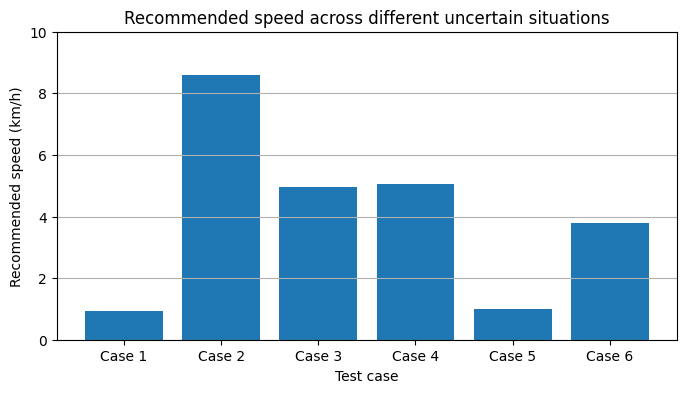

In [13]:
plt.figure(figsize=(8, 4))

labels = [f"Case {i+1}" for i in range(len(results))]
speeds = [row[3] for row in results]

plt.bar(labels, speeds)
plt.title("Recommended speed across different uncertain situations")
plt.xlabel("Test case")
plt.ylabel("Recommended speed (km/h)")
plt.ylim(0, 10)
plt.grid(axis="y")
plt.show()

In [ ]:
'''
TASK 1 - add a new rule
-IF visibility is high AND battery is low AND obstacle distance is far THEN speed is moderate

question : 

Does this rule change the result for the case below?
visibility = 85
obstacle distance = 9
battery = 25

answer:
no, the result did not change, because the R9 is a logical subset of R6. R9 only adds a condition which restricts when the rule fires , but it could never produce a higher strength than R6. Taking into consideration that fuzzy_and uses min() and . R9 could never exceed R6, than the value cannot change.

'''

In [14]:
def mamdani_robot_speed_new_rule(input_visibility, input_distance, input_battery, verbose=True):
    # Fuzzification
    V = {
        name: membership_at(input_visibility, visibility, values)
        for name, values in visibility_sets.items()
    }

    D = {
        name: membership_at(input_distance, distance, values)
        for name, values in distance_sets.items()
    }

    B = {
        name: membership_at(input_battery, battery, values)
        for name, values in battery_sets.items()
    }

    # Rule activation strengths
    rules = []

    strength = fuzzy_or(V["low"], D["close"])
    rules.append(("R1: low visibility OR close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["close"])
    rules.append(("R2: medium visibility AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], D["medium"])
    rules.append(("R3: medium visibility AND medium obstacle -> slow", strength, "slow"))

    strength = fuzzy_and(V["high"], D["medium"])
    rules.append(("R4: high visibility AND medium obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(V["high"], D["far"], B["high"])
    rules.append(("R5: high visibility AND far obstacle AND high battery -> fast", strength, "fast"))

    strength = fuzzy_and(B["low"], D["far"])
    rules.append(("R6: low battery AND far obstacle -> moderate", strength, "moderate"))

    strength = fuzzy_and(B["low"], D["close"])
    rules.append(("R7: low battery AND close obstacle -> very slow", strength, "very_slow"))

    strength = fuzzy_and(V["medium"], B["medium"], D["far"])
    rules.append(("R8: medium visibility AND medium battery AND far obstacle -> moderate", strength, "moderate"))
    
    strength= fuzzy_and(V["high"], B["low"], D["far"])
    rules.append(("R9: high visibility AND low battery AND far obstacle -> moderate",strength,"moderate"))

    # Apply Mamdani implication
    clipped_outputs = []
    for _, strength, consequent_name in rules:
        clipped_outputs.append(apply_rule(strength, speed_sets[consequent_name]))

    # Aggregate all rule conclusions
    aggregated = aggregate_outputs(*clipped_outputs)

    # Defuzzification
    crisp_speed = centroid_defuzzification(speed, aggregated)

    if verbose:
        print("Input values")
        print(f"  Visibility: {input_visibility}%")
        print(f"  Obstacle distance: {input_distance} m")
        print(f"  Battery level: {input_battery}%")
        print()

        print("Fuzzified inputs")
        print("  Visibility:", V)
        print("  Distance:", D)
        print("  Battery:", B)
        print()

        print("Rule activations")
        for rule_text, strength, consequent_name in rules:
            print(f"  {rule_text}: strength = {strength:.3f}")

        print()
        print(f"Crisp recommended speed: {crisp_speed:.2f} km/h")

    return crisp_speed, aggregated, rules

In [15]:
old_crisp, _, _ = mamdani_robot_speed(85, 9, 25, verbose=True)
new_crisp, _, _ = mamdani_robot_speed_new_rule(
    input_visibility=85,
    input_distance=9,
    input_battery=25
)

Input values
  Visibility: 85%
  Obstacle distance: 9 m
  Battery level: 25%

Fuzzified inputs
  Visibility: {'low': np.float64(0.0), 'medium': np.float64(0.0), 'high': np.float64(1.0)}
  Distance: {'close': np.float64(0.0), 'medium': np.float64(0.0), 'far': np.float64(1.0)}
  Battery: {'low': np.float64(0.75), 'medium': np.float64(0.0), 'high': np.float64(0.0)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.000
  R2: medium visibility AND close obstacle -> very slow: strength = 0.000
  R3: medium visibility AND medium obstacle -> slow: strength = 0.000
  R4: high visibility AND medium obstacle -> moderate: strength = 0.000
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.750
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: strength = 0.000

Crisp recommended speed: 

In [20]:
'''
TASK 2 
change the shape of a fuzzy set

original :
"close": trapezoidal(distance, 0, 0, 1.5, 3.5)
try this:
"close": trapezoidal(distance, 0, 0, 2.5, 5.0)

question:
what happenes to the recommended speed when the obstacle distance is around 4 meters ?

answer:
the recommended speed is lowered 
with the original shape 4 meters is outside the close zone completly 
with the wider shape , it is partially inside the close zone , and therefore it triggers a rule that wasn't initially triggered, changing the result.
'''

'\nTASK 2 \nchange the shape of a fuzzy set\n\noriginal :\n"close": trapezoidal(distance, 0, 0, 1.5, 3.5)\ntry this:\n"close": trapezoidal(distance, 0, 0, 2.5, 5.0)\n\nquestion:\nwhat happenes to the recommended speed when the obstacle distance is around 4 meters ?\n\nanswer:\nthe recommended speed is lowered \nwith the original shape 4 meters is outside the close zone completly \n\n'

In [19]:
# Original
distance_sets["close"] = trapezoidal(distance, 0, 0, 1.5, 3.5)
crisp, aggregated, rules = mamdani_robot_speed(70, 4, 80)

# Modified
distance_sets["close"] = trapezoidal(distance, 0, 0, 2.5, 5.0)
crisp, aggregated, rules = mamdani_robot_speed(70, 4, 80)

Input values
  Visibility: 70%
  Obstacle distance: 4 m
  Battery level: 80%

Fuzzified inputs
  Visibility: {'low': np.float64(0.0), 'medium': np.float64(0.2), 'high': np.float64(0.6)}
  Distance: {'close': np.float64(0.0), 'medium': np.float64(0.6666666666666666), 'far': np.float64(0.0), 'sets': np.float64(0.4)}
  Battery: {'low': np.float64(0.0), 'medium': np.float64(0.0), 'high': np.float64(1.0)}

Rule activations
  R1: low visibility OR close obstacle -> very slow: strength = 0.000
  R2: medium visibility AND close obstacle -> very slow: strength = 0.000
  R3: medium visibility AND medium obstacle -> slow: strength = 0.200
  R4: high visibility AND medium obstacle -> moderate: strength = 0.600
  R5: high visibility AND far obstacle AND high battery -> fast: strength = 0.000
  R6: low battery AND far obstacle -> moderate: strength = 0.000
  R7: low battery AND close obstacle -> very slow: strength = 0.000
  R8: medium visibility AND medium battery AND far obstacle -> moderate: stre

In [ ]:
'''
TASK 3 
compare mamdani with a crisp rule system 

Write a simple crisp rule-based system using if, elif, and else.

IF visibility < 40 OR obstacle_distance < 3 THEN speed = 2
ELSE IF visibility > 70 AND obstacle_distance > 7 AND battery > 60 THEN speed = 8
ELSE speed = 5

compare the crisp rule based system with the mamdani fuzzy system

questions:
Which system changes more smoothly when inputs change?
->Mamdani changes more smoothly because there an input can partially belong to multiple categories simultaneously.
Which system is easier to interpret?
->The crisp system is easier to interpret , the rules are like plain logic. For mamdani is not a single reason for the output, it's a blend of multiple rules with different weights .
Which system is more sensitive to threshold choices?
-> The crisp system is more sensitive to threshold choices, for example, being at 39 gives 2 speed, if you go one step up, at 40, it jumps at 5, it's a big difference commng from a small modification.
In what real-world situations would the fuzzy system be more appropriate?
-> usually where inputs are continuous , not fixed, mixed and blended, drones for example, the speed shouldn't jump from a low one to a high one , it should go smoothly, same for vehichles with (pilot automat ) 
'''

In [21]:
def crisp_rule_robot_speed(input_visibility, input_distance, input_battery):
    if input_visibility < 40 or input_distance < 3:
        return 2.0
    elif input_visibility > 70 and input_distance > 7 and input_battery > 60:
        return 8.0
    elif input_battery < 30:
        return 4.0
    else:
        return 5.0


comparison_cases = [
    (39, 5, 80),
    (40, 5, 80),
    (41, 5, 80),
    (75, 7.1, 80),
    (75, 6.9, 80),
]

print("Visibility | Distance | Battery | Crisp rules | Mamdani")
print("-" * 62)

for v, d, b in comparison_cases:
    crisp_rule_value = crisp_rule_robot_speed(v, d, b)
    mamdani_value, _, _ = mamdani_robot_speed(v, d, b, verbose=False)
    print(f"{v:10.1f} | {d:8.1f} | {b:7.1f} | {crisp_rule_value:11.2f} | {mamdani_value:7.2f}")

Visibility | Distance | Battery | Crisp rules | Mamdani
--------------------------------------------------------------
      39.0 |      5.0 |    80.0 |        2.00 |    2.46
      40.0 |      5.0 |    80.0 |        5.00 |    2.55
      41.0 |      5.0 |    80.0 |        5.00 |    2.63
      75.0 |      7.1 |    80.0 |        8.00 |    7.37
      75.0 |      6.9 |    80.0 |        5.00 |    7.09
